# 단일표본검정

- 1. 정규성 만족 여부 파악
scipy.stats.shaprio(d1)

- 1-1. shapiro 값이 0.05 이하로 정규성을 만족하지 못하는 경우
scipy.stats.wilcoxon(t - exp)

- 1-2. shapiro 값이 0.05 이상으로 정규성을 만족하는 경우
scipy.stats.ttest_1samp(t, exp)

## 정규성을 만족하지 못하는 경우


ShapiroResult(statistic=np.float64(0.9320667756543998), pvalue=np.float64(6.532290558584551e-05))
WilcoxonResult(statistic=array([0.]), pvalue=array([3.74680733e-18]))


<Axes: xlabel='value', ylabel='Count'>

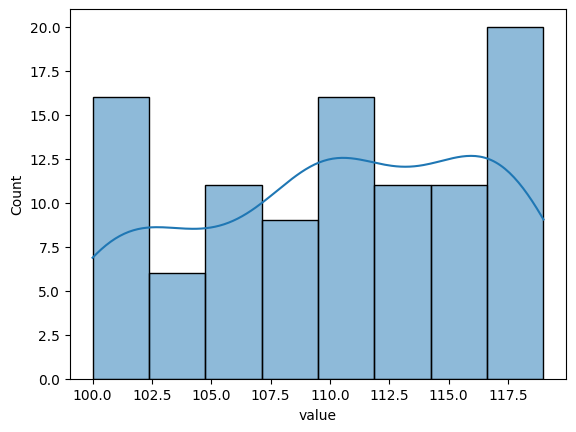

In [11]:
# 단일표본검정
from scipy import stats
import numpy as np
import pandas as pd

# 임의의 DataFrame을 생성
t = np.random.randint(100, 120, size = 100)
t = pd.DataFrame({'value' : t})
t

# 기대값 생성
exp = 120

# 정규성 검정
from scipy import stats
print(stats.shapiro(t))
# ShapiroResult(statistic=np.float64(0.9522866114477813), pvalue=np.float64(0.0011771780064101503))
# 정규성을 만족하지 못한다는 대립가설을 채택한다

print(stats.wilcoxon(t - exp))
# WilcoxonResult(statistic=array([0.]), pvalue=array([3.77379727e-18]))
# 대립가설 을 채택한다

# stats.ttest_1samp()

# 정규성 여부를 시각적으로도 확인하고 싶다
import seaborn as sns
sns.histplot(t['value'], kde=True)


## 정규성을 만족하는 경우  


In [12]:
# 만약 정규성을 만족하는 데이터다

import numpy as np
import pandas as pd

# 평균이 110, 표준편차가 5인 정규분포에서 100개 샘플 생성
values = np.random.normal(loc=110, scale=5, size=100)

# 데이터프레임 생성
t = pd.DataFrame({'value': values})

ShapiroResult(statistic=np.float64(0.9848597441800536), pvalue=np.float64(0.3102689818765684))
TtestResult(statistic=array([-19.75266752]), pvalue=array([4.04407583e-36]), df=array([99]))


<Axes: xlabel='value', ylabel='Count'>

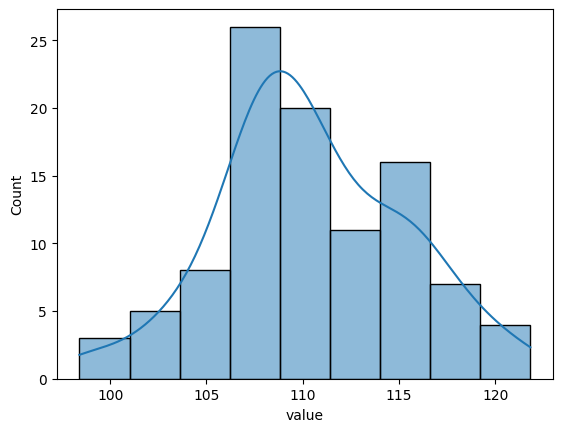

In [18]:
# 정규성 검정을 실시

from scipy import stats

print(stats.shapiro(t))
# ShapiroResult(statistic=np.float64(0.9848597441800536), pvalue=np.float64(0.3102689818765684))
# shapiro 값이 0.05 이상으로, 정규성을 만족한다, 정규성 불만족이라는 대립가설을 받아들이지 않는다
# 정규성을 만족하므로 ttest 검정을 실시합니다.

from scipy import stats
print(stats.ttest_1samp(t, exp))
# TtestResult(statistic=array([-19.75266752]), pvalue=array([4.04407583e-36]), df=array([99]))
# ttest p-value 값 0.05 이하로 매우 작다. 대립가설을 채택 합니다.

# 정규성 여부를 시각적으로도 확인하고 싶다
import seaborn as sns
sns.histplot(t['value'], kde=True)

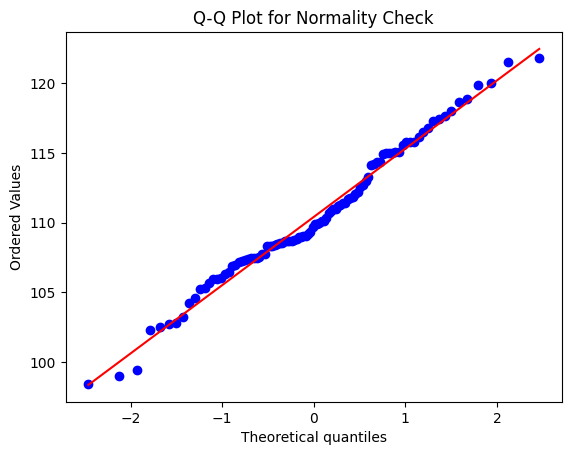

In [19]:
# qq-plot 을 통해서도 데이터 정규성을 세밀하게 관찰할 수 있다
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(t['value'], dist="norm", plot=plt)
plt.title("Q-Q Plot for Normality Check")
plt.show()


# 대응표본검정 / ABT


In [ ]:
# 시나리오
# A 기업은 X 기능 배포를 위해 ABT 를 실시하였다.
# ABT 실시 결과는 데이터프레임 결과값으로 제시되며 실험군, 대조군 순으로 구성되어 있다.
# 데이터 분석팀은 ABT 결과값을 통해서 X 기능 배포 여부를 판단하고자 한다.

# t1 : Control group, 대조군, 어떠한 조치가 시행되지 않은 그룹
# t2 : Test group, 실험군, 테스트 기능을 적용한 그룹입니다.

import numpy as np
import pandas as pd

t1 = np.random.choice([0, 1], size = 100, p = [0.5, 0.5])
t2 = np.random.choice([0, 1], size = 100, p = [0.3, 0.7])


## 정규성을 만족하지 못하는 경우


In [26]:
# 정규성 만족 여부를 먼저 평가
from scipy import stats

diff = t1 - t2
print(stats.shapiro(diff))
# ShapiroResult(statistic=np.float64(0.8003467542541362), pvalue=np.float64(2.5374694035033606e-10))
# 유의수준보다 매우 적은 p-value, 대립가설을 채택한다. 정규성을 만족하지 못한다.

# 정규성을 만족하지 못하므로, wilcoxon signed rank 검정을 수행 합니다.

from scipy import stats
print(stats.wilcoxon(t1, t2))
# WilcoxonResult(statistic=np.float64(522.5), pvalue=np.float64(0.02945638563257136))
# 유의수준보다 적게 나온 p-value, 대립가설을 채택한다. 기능 X의 적용 이후 소비자의 사용 빈도 변화 여부를 통계적으로 확인하였습니다.


# 실제 test group 의 사용(1) 수 증대 여부를 통계적으로 평가할 수 있는가?
# wilcoxon(실험군, 대조군, alternative = 실험군의 크기에 따라 'two-sided', 'greater', 'less')
# 여기서는 t2 실험군의 사용(1) 수가 더 높은지 를 통계적으로 추가 검증을 수행할 것이기 때문에, t2, t1 순으로, alternative = 'greater' 로 놓고 평가를 진행하겠습니다.

from scipy import stats
print(stats.wilcoxon(t2, t1, alternative = 'greater'))
# WilcoxonResult(statistic=np.float64(962.5), pvalue=np.float64(0.01472819281628568))
# 단측검정을 통해 실험군의 greater than 대조군 여부를 평가하였고, p-value 값이 유의수준보다 낮다. '기능 X의 사용성 증대' 여부를 통계적으로 증명하였습니다. 본 ABT 를 통해 X 기능의 적용 및 배포를 진행하셔도 좋을 것으로 사료 됩니다.


ShapiroResult(statistic=np.float64(0.8003467542541362), pvalue=np.float64(2.5374694035033606e-10))
WilcoxonResult(statistic=np.float64(522.5), pvalue=np.float64(0.02945638563257136))
WilcoxonResult(statistic=np.float64(962.5), pvalue=np.float64(0.01472819281628568))


## 문장 다듬기

In [ ]:
# 표현이 너무 강하기 때문에 원활한 표현으로 제시합니다.
# 단측 Wilcoxon 검정 결과, 실험군(t2)의 사용률이 대조군(t1)보다 **통계적으로 유의미하게 높음**이 확인되었습니다 (p = 0.0147 < 0.05).
# 이는 기능 X 적용 이후 **사용자 행동 변화가 긍정적인 방향으로 발생했음을 시사**합니다.
# 따라서 본 AB 테스트 결과에 기반하여 기능 X의 정식 배포를 **데이터 기반으로 뒷받침할 수 있습니다.**


## 정규성을 만족하는 경우

In [27]:
# 이번에는 정규성을 만족하는 경우를 가정하여 ABT 성과를 통계적으로 분석 해보겠습니다.

# 시나리오
# 앱 체류 시간 증가 실험
# A사는 앱 내 기능 X (예: 추천 알고리즘, UI 개선 등)를 적용했을 때, 사용자의 앱 체류 시간이 증가했는지 통계적으로 확인하고 싶습니다.
# 아래 데이터는 t1, t2 로 구성되어 있고, t1의 경우 대조군, t2의 경우 신규 기능 적용 이후 앱 체류 시간을 의미 합니다.

# 시드 고정 (재현 가능성)
np.random.seed(0)

# 정규성을 만족하는 실수형 데이터 생성
# 평균이 50, 표준편차가 10인 정규분포에서 각각 생성
t1 = np.random.normal(loc=50, scale=10, size=100)       # 대조군 (before)
t2 = t1 + np.random.normal(loc=3, scale=5, size=100)    # 실험군 (after, 평균 증가)


In [32]:
# 두 데이터가 정규성을 만족하는지 여부를 먼저 확인 해보겠습니다.

from scipy import stats

diff = t1 - t2
print(stats.shapiro(diff))
# ShapiroResult(statistic=np.float64(0.9735488248836262), pvalue=np.float64(0.04156432925498737))
# shapiro 검정 결과 p-value 가 0.05 이하로, 귀무가설인 '정규성을 만족한다'를 기각합니다. 대립가설인 '정규성을 만족하지 못한다'를 채택 합니다.

# 다만
# 단일 p-value가 0.05보다 작게 나왔다고 해서 반드시 정규성 자체가 없다고 단정할 수는 없습니다.
# Shapiro-Wilk 검정은 작은 샘플에서 민감하게 작동하며, 정규분포에서 샘플링한 데이터조차 기각될 수 있습니다.
# 하여, 정규성을 만족한다는 가정 하에, ttest_rel 함수를 통한 t검정을 실시 하겠습니다.


from scipy import stats
print(stats.ttest_rel(t2, t1, alternative = 'greater'))
# 실험군 t2 가 더 높은지에 대한 가설 검정을 실시하기 때문에, alternative 파라미터를 greater로 주어 검정을 시행하였습니다.
# TtestResult(statistic=np.float64(6.558577199407085), pvalue=np.float64(1.2455578779167676e-09), df=np.int64(99))
# pvalue 결과는 유의수준 0.05 보다 매우 적은 수치로, 귀무가설을 기각, 대립가설을 채택할 수 있는 통계적 유의성을 확인하였습니다.
# 이로서, 대립가설인 '실험군 t2의 앱 기능 x 적용 이후 체류 시간이 증대되었다' 실효성을 통계적으로 증명하였으며, 해당 기능의 배포를 제안 드립니다.


ShapiroResult(statistic=np.float64(0.9735488248836262), pvalue=np.float64(0.04156432925498737))
TtestResult(statistic=np.float64(6.558577199407085), pvalue=np.float64(1.2455578779167676e-09), df=np.int64(99))
TtestResult(statistic=np.float64(6.558577199407085), pvalue=np.float64(2.4911157558335352e-09), df=np.int64(99))


## 문장 다듬기

In [ ]:

# Shapiro-Wilk 정규성 검정 결과, p-value는 0.0415로 유의수준 0.05보다 작았습니다.
# 이에 따라 귀무가설(H₀: 정규성을 따른다)을 기각하고, 대립가설(H₁: 정규성을 따르지 않는다)을 채택하게 됩니다.

# 단, 단일 p-value가 유의수준을 살짝 밑돈다고 해서 정규성 자체가 없다고 단정하긴 어렵습니다.
# Shapiro-Wilk 검정은 정규분포에서 샘플링한 데이터조차 작은 편차에 민감하게 반응할 수 있으며,
# 실제로 본 데이터는 np.random.normal()을 사용해 생성된 것으로, 정규성을 가정해도 무방하다고 판단됩니다.

# 따라서, 정규성을 만족하는 것으로 가정하고, 대응표본 t-검정을 수행하였습니다.

stat, p = stats.ttest_rel(t2, t1, alternative='greater')
print(f"t-stat = {stat:.3f}, p-value = {p:.5f}")

# 실험군 t2가 대조군 t1보다 평균적으로 큰지 검정하기 위해 alternative='greater'를 설정하였고,
# t-test 결과 p-value가 1.25e-09로 유의수준 0.05보다 훨씬 작았습니다.
# 이에 따라 귀무가설(H₀: t2 ≤ t1)을 기각하고, 대립가설(H₁: t2 > t1)을 채택할 수 있습니다.

# 결론적으로, 실험군에서 앱 체류 시간이 통계적으로 유의미하게 증가한 것으로 판단되며,
# 기능 X의 정식 배포를 위한 데이터 기반 근거를 확보하였습니다.


# 독립표본검정

## 정규성을 만족하고 등분산성을 만족하는 케이스

In [40]:
# 시나리오
# 광고 문구 A/B 테스트 – 전환율 변화
# 마케팅 팀은 광고 문구 두 가지(A/B)를 실험하고 있습니다.
# 각 문구를 본 사용자들의 **구매 전환율(%)**을 비교하여 어떤 문구가 더 효과적인지 검정하고자 합니다.

# 데이터셋은 정규성과 등분산성을 만족한다는 가정 하에 생성하였으며, 만족 여부를 통계적으로 해석하고자 합니다.
import numpy as np

# 시드 고정 (재현 가능성)
np.random.seed(42)

# 그룹 A: 광고 문구 A를 본 그룹 (평균 12%, 표준편차 2%)
group_a = np.random.normal(loc=12, scale=2, size=100)

# 그룹 B: 광고 문구 B를 본 그룹 (평균 14%, 표준편차 2%)
group_b = np.random.normal(loc=14, scale=2, size=100)

# 두 그룹의 데이터는 정규성을 만족하는가?
from scipy import stats

print(stats.shapiro(group_a))
print(stats.shapiro(group_b))
# ShapiroResult(statistic=np.float64(0.9898833815158512), pvalue=np.float64(0.6551676754214463))
# ShapiroResult(statistic=np.float64(0.9775339933952859), pvalue=np.float64(0.08525602813445946))
# group_a, group_b의 pvalue 값 모두 유의수준 이상이므로, 귀무가설을 기각할 수 없습니다. 두 그룹은 정규성을 가지고 있음을 통계적으로 해석할 수 있습니다.

# 이어 등분산성 검정을 수행하겠습니다.
from scipy import stats
print(stats.levene(group_a, group_b))

# LeveneResult(statistic=np.float64(0.18038307844285065), pvalue=np.float64(0.6715053895987058))
# 레빈 검정의 pvalue 값은 유의수준 이상으로, 귀무가설을 기각할 수 없습니다. 두 데이터 간 등분산성을 갖고 있음을 통계적으로 해석할 수 있겠습니다.

# 정규성과 등분산성을 통계적으로 증명하였기에, 이어 ttest_ind 를 통해 t검정을 수행하겠습니다.

from scipy import stats
print(stats.ttest_ind(group_a, group_b, equal_var = True))
# TtestResult(statistic=np.float64(-8.551459943248743), pvalue=np.float64(3.292961428703462e-15), df=np.float64(198.0))
# 두 데이터 간 등분산성을 띄고 있으므로 equal_var 옵션은 True입니다.
# 독립표본검정 결과 유의수준보다 낮은 pvalue 값을 확인하였으며, 이를 통해 통계적으로, 광고 문구 간 효과성은 차이가 있다고 해석할 수 있겠습니다.

# 그러면 두 그룹 간 어디가 더 효과적이다 라는 걸 증명하기 위해 단측 검정을 실시하겠습니다.
# 대립가설은 group_b가 더 크다 로 설정하여 단측 검정을 실시 하겠습니다.
from scipy import stats
print(stats.ttest_ind(group_b, group_a, equal_var = True, alternative = 'greater'))
# TtestResult(statistic=np.float64(8.551459943248743), pvalue=np.float64(1.646480714351731e-15), df=np.float64(198.0))
# 유의수준보다 낮은 pvalue 값을 통해, 대립가설을 채택합니다. group_b가 보다 고성과임을 지지할 수 있는 통계적 근거를 확인할 수 있었습니다.
# 위 통계 내용을 통해 group_b의 광고 문구 적용을 제안 드립니다.


ShapiroResult(statistic=np.float64(0.9898833815158512), pvalue=np.float64(0.6551676754214463))
ShapiroResult(statistic=np.float64(0.9775339933952859), pvalue=np.float64(0.08525602813445946))
LeveneResult(statistic=np.float64(0.18038307844285065), pvalue=np.float64(0.6715053895987058))
TtestResult(statistic=np.float64(-8.551459943248743), pvalue=np.float64(3.292961428703462e-15), df=np.float64(198.0))
TtestResult(statistic=np.float64(8.551459943248743), pvalue=np.float64(1.646480714351731e-15), df=np.float64(198.0))


## 문장 다듬기

In [ ]:
#
# 그룹 B의 평균 전환율은 약 14.1%, 그룹 A는 약 11.9%로 2%p 이상의 차이를 보였습니다.
# 단측 t-검정 결과, p-value는 유의수준 0.05보다 매우 낮은 1.6e-15로 나타났으며, 이는 광고 문구 B가 A보다 유의미하게 효과적임을 통계적으로 지지합니다.
# 따라서 문구 B의 채택을 제안드립니다.

# 단순히 평균이 높습니다. 라는 근거와, 평균이 높고, 통계적으로도 유의미성을 갖는다 라는 근거를 같이 제시함으로서 갖는 의미가 궁금합니다.
# 단순 평균 차이는 “그냥 높다”는 설명이고, 통계적 유의성은 **“우연일 확률은 거의 없고, 일반화 가능한 근거 있는 차이”**임을 입증하는 것입니다.

## 정규성을 만족하지만 등분산성을 만족하지 않는 케이스

In [41]:
# 시나리오
# 마케팅 팀은 두 개의 서로 다른 소셜미디어 채널 (예: 인스타그램 vs 유튜브)을 통해 동일한 광고를 집행했습니다.
# 각 채널을 통해 **유입된 사용자들의 구매 전환율(%)**을 분석하여, 어느 채널이 더 효과적인지를 통계적으로 검증하고자 합니다.

# 가정 조건:
# 두 채널 모두 정규분포에서 유입되는 전환율을 보인다. (정규성 만족)
# 하지만 유입되는 사용자 수나 사용자의 특성이 다르기 때문에 전환율의 분산은 다름 (등분산성 불만족)

import numpy as np

# 시드 고정 (재현 가능성)
np.random.seed(42)

# 인스타그램 그룹: 평균 13%, 표준편차 2%
instagram = np.random.normal(loc=13, scale=2, size=100)

# 유튜브 그룹: 평균 14%, 표준편차 5% (분산 큼)
youtube = np.random.normal(loc=14, scale=5, size=100)

In [47]:
# 문제를 정의하겠습니다.

# 문제정의 : 매체별 구매 전환율 분석 통해 전환효율 측정
# 분석방법 : 독립표본검정, 단측검정
# 분석과정 :
#    - 전환율 평균 산출
#    - 데이터 그룹 간 정규성 검정 실시
#    - 데이터 그룹 간 등분산성 검정 실시
#    - 데이터 그룹 간 독립표본검정 실시
#    - 데이터 그룹 간 단측검정 실시
# 분석결과 / 제안 :
#    - 두 그룹 중 youtube 의 전환율 1.4%p 높게 나타난 것을 확인하였으며, 이를 일반화 가능한 통계적 근거를 산출할 수 있었습니다.
#    - 이를 통해 광고 효율 증대를 위해 youtube 그룹의 예산 집중, 운영 일정 증대 등의 방안을 제안 드립니다.

# 분석세부사항 :

# 0. 두 데이터의 전환율 평균을 산출합니다.
print(np.mean(instagram))
print(np.mean(youtube))
# 12.792306965211813
# 14.111522935249617
# 이를 통해 youtube 채널의 전환율이 더 높은 것을 확인할 수 있었습니다.

# 1. 두 데이터의 정규성 검정을 실시 합니다.
from scipy import stats
print(stats.shapiro(instagram))
print(stats.shapiro(youtube))
# ShapiroResult(statistic=np.float64(0.9898833815158512), pvalue=np.float64(0.6551676754214463))
# ShapiroResult(statistic=np.float64(0.9775339933952855), pvalue=np.float64(0.08525602813445281))
# 두 그룹 모두 유의수준 이상의 pvalue 값을 가집니다. 귀무가설을 기각하지 않습니다. 두 그룹은 정규분포를 만족합니다.

# 2. 이어서 등분산성 검정을 실시하겠습니다.
from scipy import stats
print(stats.levene(instagram, youtube))
# LeveneResult(statistic=np.float64(55.36256760720919), pvalue=np.float64(2.9869220385395163e-12))
# 유의수준보다 낮은 pvalue 값을 통해, 두 데이터는 등분산성 만족하지 않음을 확인하였습니다.
# 이는 두 그룹의 사용자 특성이 다를 수 있다는 점을 의미하기도 합니다.

# 3. 등분산성을 만족하지 않음을 확인 하였으며, 이어 독립표본검정을 실시 하겠습니다.
from scipy import stats
print(stats.ttest_ind(instagram, youtube, equal_var = False))
# TtestResult(statistic=np.float64(-2.5853965642717434), pvalue=np.float64(0.01085423890672795), df=np.float64(127.13677814615725))
# 유의확률보다 더 낮은 pvalue 값을 통해 두 그룹 간 전환율 차이가 통계적으로 유의미함을 확인할 수 있었습니다. 이어 어떤 그룹의 전환율이 더 높은지에 대해 검정 수행하겠습니다.

from scipy import stats
print(stats.ttest_ind(instagram, youtube, equal_var = False, alternative = 'greater'))
# TtestResult(statistic=np.float64(-2.5853965642717434), pvalue=np.float64(0.9945728805466361), df=np.float64(127.13677814615725))

from scipy import stats
print(stats.ttest_ind(youtube, instagram, equal_var = False, alternative = 'greater'))
# TtestResult(statistic=np.float64(2.5853965642717434), pvalue=np.float64(0.005427119453363975), df=np.float64(127.13677814615725))
# youtube 그룹의 높은 전환율 수치가 통계적으로 유의미한지를 판단한 결과, 유의수준보다 더 낮은 pvalue를 가지는 것을 확인하였으며, 이는 youtube의 전환율이 더 높은 점에 대해 일반화 가능한 근거 있는 차이가 있음을 방증할 수 있습니다.



12.792306965211813
14.111522935249617
ShapiroResult(statistic=np.float64(0.9898833815158512), pvalue=np.float64(0.6551676754214463))
ShapiroResult(statistic=np.float64(0.9775339933952855), pvalue=np.float64(0.08525602813445281))
LeveneResult(statistic=np.float64(55.36256760720919), pvalue=np.float64(2.9869220385395163e-12))
TtestResult(statistic=np.float64(-2.5853965642717434), pvalue=np.float64(0.01085423890672795), df=np.float64(127.13677814615725))
TtestResult(statistic=np.float64(-2.5853965642717434), pvalue=np.float64(0.9945728805466361), df=np.float64(127.13677814615725))
TtestResult(statistic=np.float64(2.5853965642717434), pvalue=np.float64(0.005427119453363975), df=np.float64(127.13677814615725))


## 문장 다듬기

In [ ]:
# 🧠 통계 해석 개선 포인트
# 1. equal_var=False에 대한 해석
#다만 **"등분산성 가정을 만족하지 않기 때문에 Welch’s t-test (equal_var=False)를 사용한다"**는 문장을 명확히 쓰면 좋습니다.
#
#등분산성을 만족하지 않으므로, 등분산 가정을 하지 않는 Welch’s t-test를 수행하였습니다.

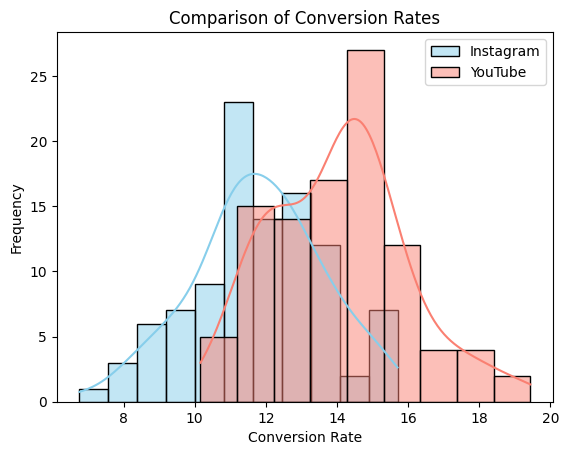

In [50]:
# 시각화를 통한 전환율 차이 가시화

import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(group_a, kde=True, color="skyblue", label="Instagram")
sns.histplot(group_b, kde=True, color="salmon", label="YouTube")
plt.legend()
plt.title("Comparison of Conversion Rates")
plt.xlabel("Conversion Rate")
plt.ylabel("Frequency")
plt.show()

# 다음은 두 그룹 간 전환율 분포를 시각화한 사항이며, youtube그룹의 conversion rate distribution이 instagram 대비 높게 형성되어 있음을 시각적으로 파악할 수 있습니다.

In [51]:
# Cohen's d 계산 함수
def cohen_d(x, y):
    nx = len(x)
    ny = len(y)
    pooled_std = np.sqrt(((nx - 1) * np.std(x, ddof=1) ** 2 + (ny - 1) * np.std(y, ddof=1) ** 2) / (nx + ny - 2))
    return (np.mean(x) - np.mean(y)) / pooled_std

# 예시 사용
d = cohen_d(group_b, group_a)
print("Cohen's d:", round(d, 3))

# Cohen's d 값을 통해 두 그룹 간 효과 차이의 크기를 통계적으로 검증 실시 하였으며
# "Cohen's d: 1.209" 값을 통해 Youtube 그룹의 마케팅 효과가 매우 크다는 점을 통계적으로 파악할 수 있었습니다.

Cohen's d: 1.209


### Cohen's d
| Cohen’s d | 의미                |
| --------- | ----------------- |
| 0.2 미만    | 매우 작은 차이          |
| 0.2–0.5   | 작은 효과             |
| 0.5–0.8   | 중간 정도 효과          |
| 0.8 이상    | 큰 효과 (**설득력 있음**) |


## 정규성을 만족하지 못하는 케이스

In [52]:
# - 시나리오 :
# 신규 프로모션에 따른 유입 고객 수 비교 (정규성 불만족)
# 마케팅 팀은 **프로모션 A (기존 방식)**와 **프로모션 B (신규 이벤트)**를 각각 적용했습니다. 각 프로모션 이후 1일 단위 유입 고객 수를 30일간 기록했습니다.
# 유입 수는 정규 분포를 따르지 않는 것으로 판단되어 **비모수 검정 (mannwhitneyu)**으로 비교합니다.

# 데이터셋 생성
import numpy as np
import pandas as pd
from scipy import stats

np.random.seed(42)

# 프로모션 A: 기존 방식 → 전체적으로 낮고 균일한 분포 (right-skewed)
promo_a = np.random.exponential(scale=10, size=30)

# 프로모션 B: 신규 이벤트 → 더 높은 유입을 유도했지만 분포는 여전히 비정규
promo_b = np.random.exponential(scale=15, size=30)


8.05800306066029
16.188303569378544
ShapiroResult(statistic=np.float64(0.7952566641156658), pvalue=np.float64(5.3793267943225934e-05))
ShapiroResult(statistic=np.float64(0.8380024914325631), pvalue=np.float64(0.00035124792723220465))
MannwhitneyuResult(statistic=np.float64(565.0), pvalue=np.float64(0.090490360906144))
MannwhitneyuResult(statistic=np.float64(565.0), pvalue=np.float64(0.045245180453072))
MannwhitneyuResult(statistic=np.float64(565.0), pvalue=np.float64(0.9561448112595093))


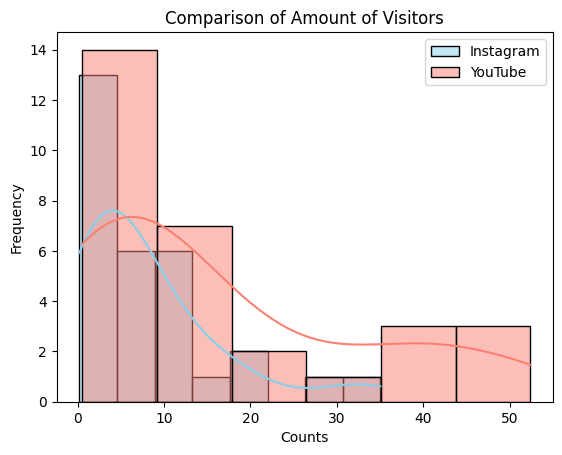

Cohen's d: 0.624


In [67]:
# - 문제정의 : 프로모션 A, B 의 일별 유입 고객 수 차이 분석, 고성과 프로모션 선별
# - 목표설정 : 고성과 프로모션 종류 파악, 일반화 위한 통계적 검정 수행, 이를 통해 마케팅 인사이트 제안
# - 분석방법 : 정규성, 독립표본검정
# - 분석결과 / 제안 :
#    - promo_b 그룹의 일 평균 방문 수는 a 그룹 대비 약 2배 수준임을 확인 하였습니다.
#    - 위 성과의 통계적 유의성 검증을 통해 일반화 가능한 통계적 근거를 확보할 수 있었습니다.
#    - 하여 promo_b의 예산 집중, 운영 일정 증대 등의 방안을 제안 드립니다.

# - 분석상세 :
# 0. 두 그룹의 유입 고객 수 평균을 통해 1차 성과 측정을 진행 하겠습니다.

print(np.mean(promo_a))
print(np.mean(promo_b))
# 8.05800306066029
# 16.188303569378544

# promo_b 평균이 약 2배 수준으로 높은 것을 파악 할 수 있었습니다.

# 1. 0.의 산출 결론을 일반화할 수 있는지에 대한 통계적 근거를 파악하겠습니다.
# 두 데이터의 정규성을 검정합니다.

from scipy import stats
print(stats.shapiro(promo_a))
print(stats.shapiro(promo_b))
# ShapiroResult(statistic=np.float64(0.7952566641156658), pvalue=np.float64(5.3793267943225934e-05))
# ShapiroResult(statistic=np.float64(0.8380024914325631), pvalue=np.float64(0.00035124792723220465))
# 유의수준 대비 낮은 두 그룹의 pvalue 값을 통해, '정규성을 충족한다' 귀무가설을 기각, '정규성을 충족하지 않는다' 대립가설을 채택 합니다.

# 2. 정규성을 만족하지 않는 두 그룹의 독립표본검증을 위해 mannwhitneyu 검정을 시행하겠습니다.

from scipy import stats
print(stats.mannwhitneyu(promo_b, promo_a))
# MannwhitneyuResult(statistic=np.float64(565.0), pvalue=np.float64(0.090490360906144))
# 유의수준보다 높은 pvalue 값을 통해, 두 유입고객 수 평균 차이(크고 작음 구분 없이)에 대해 일반화를 통계적으로 증명하기에는 제한이 있음을 확인할 수 있었습니다.

# 3. promo_b가 promo_a 보다 높았다 라는 성과를 통계적으로 일반화할 수 있는지에 대해서도 추가 검증해보겠습니다.
# 이는 '차이'가 아니라 'b 프로모션 성과가 더 높았다' 라는 측면에서만 통계적인 유의성을 갖는지에 대한 검증 과정입니다.
from scipy import stats
print(stats.mannwhitneyu(promo_b, promo_a, alternative = 'greater'))
# MannwhitneyuResult(statistic=np.float64(565.0), pvalue=np.float64(0.045245180453072))

## 반대 케이스 검정
from scipy import stats
print(stats.mannwhitneyu(promo_b, promo_a, alternative = 'less'))
# MannwhitneyuResult(statistic=np.float64(565.0), pvalue=np.float64(0.9561448112595093))

# 두 결과값을 통해
# promo_b 그룹이 promo_a 대비 유입고객 수 평균이 높다라는 가설 검증을 통해 유의수준보다 낮은 pvalue 값을 도출하였으며, 이를 통해 귀무가설을 기각하고 대립가설 'promo_b의 평균이 더 높다' 을 채택합니다.
# 이를 통해 promo_b 성과가 갖는 의미를, 우연이 아닌 일반화 할 수 있는 통계적 근거를 확인할 수 있었습니다.

# 4. 두 그룹별 성과 시각화를 통해 그룹별 성과 분포 수준을 공유드립니다.
import seaborn as sns

sns.histplot(promo_a, kde=True, color="skyblue", label="Instagram")
sns.histplot(promo_b, kde=True, color="salmon", label="YouTube")
plt.legend()
plt.title("Comparison of Amount of Visitors")
plt.xlabel("Counts")
plt.ylabel("Frequency")
plt.show()

# 이를 통해 Youtube 그룹의 일별 방문수 30 이상의 빈도가 Instagram 그룹 대비 높게 분포되어 있는 점을 가시적으로 확인할 수 있습니다.

# 5. 두 그룹의 프로모션이 갖는 효과의 크기 수준을 통계적으로 파악 해보겠습니다.

# Cohen's d 계산 함수
def cohen_d(x, y):
    nx = len(x)
    ny = len(y)
    pooled_std = np.sqrt(((nx - 1) * np.std(x, ddof=1) ** 2 + (ny - 1) * np.std(y, ddof=1) ** 2) / (nx + ny - 2))
    return (np.mean(x) - np.mean(y)) / pooled_std

# 결과값 도출
d = cohen_d(promo_b, promo_a)
print("Cohen's d:", round(d, 3))

# Cohen's d 값을 통해 두 그룹 간 효과 차이의 크기를 통계적으로 검증 실시 하였으며
# Cohen's d: 0.624 수치를 통해 Youtube 의 성과가.. 이 부분은 추가적인 해석이 필요할 것 같습니다..

# Cohen’s d	의미
# 0.2 미만	매우 작은 차이
# 0.2–0.5	작은 효과
# 0.5–0.8	중간 정도 효과
# 0.8 이상	큰 효과 (설득력 있음)

### 문장 다듬기

In [ ]:
# Promo_B 그룹의 평균 유입 수는 A보다 약 2배 높은 16.18명을 기록했으며, 단측 Mann–Whitney U 검정 결과 p-value=0.045로 유의미한 차이를 보였습니다.
# 또한 효과 크기 분석(Cohen’s d = 0.624)은 중간 수준의 실질적 차이가 존재함을 보여주며, 이는 마케팅 전략 수립 시 프로모션 B의 확장 적용을 설득력 있게 뒷받침하는 통계적 근거가 됩니다.
